# **OASIS INFOBYTE**

**Prepared By : Shivani Sharma**

**Level** : Level 1

**Task** : Task 2 Customer Segmentation Analysis

**Objective** : Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Tech Stack Used :** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn, Jupyter Notebook

**Data set Used :** Online Retail Dataset

**1. Import essential libraries**

In [3]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import datetime as dt

# Set visual style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


# =====================================================

# TASK 1 : DATA LOADING & DATA CLEANING

# =====================================================

**2. Load Dataset**

In [4]:
df = pd.read_csv(r'F:/OasisiInfobyte/Level_1/Task_2(Customer Segmentation Analysis)/cleaned_transactions.csv')

**3. Inspect Dataset**

# **Dataset First View**

In [7]:
# 1. Display first 5 Rows

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerType
0,580513,23320,GIANT 50'S CHRISTMAS CRACKER,3,2011-12-04 13:59:00,1.25,14456.0,United Kingdom,Registered
1,580514,22800,ANTIQUE TALL SWIRLGLASS TRINKET POT,1,2011-12-04 14:01:00,3.75,16905.0,United Kingdom,Registered
2,580514,21344,MOROCCAN BEATEN METAL DISH,1,2011-12-04 14:01:00,9.95,16905.0,United Kingdom,Registered
3,580514,23084,RABBIT NIGHT LIGHT,1,2011-12-04 14:01:00,2.08,16905.0,United Kingdom,Registered
4,580514,21790,VINTAGE SNAP CARDS,1,2011-12-04 14:01:00,0.85,16905.0,United Kingdom,Registered


**Understanding the Online Retail Dataset**

An Online Retail dataset contains transactional data from an e-commerce business. It records individual purchasing activities of customers, including what items were bought, in what quantities, at what time, for what price, and by which customer.

Analyzing this dataset allows us to understand customer shopping behaviors, calculate customer lifetime value, and perform RFM (Recency, Frequency, Monetary) segmentation for targeted marketing strategies.

**Column Descriptions & Insights**

Based on our df.head() inspection, here is the functional explanation of each feature in the dataset:

| Column Name | Data Type | Description / Functional Meaning |
| :--- | :--- | :--- |
| **InvoiceNo** | Categorical / Int | Unique transaction identifier for each order. |
| **StockCode** | Categorical / String | Unique code assigned to each specific product. |
| **Description** | Text / String | Name/title describing the product item. |
| **Quantity** | Numerical / Int | Number of units purchased per transaction line. |
| **InvoiceDate** | Datetime | Date and time when the transaction occurred. |
| **UnitPrice** | Numerical / Float | Price per single unit of the product. |
| **CustomerID** | Categorical / Float | Unique identification number for each customer. |
| **Country** | Categorical / String | Location/Country where the customer is located. |
| **CustomerType** | Categorical / String | Type of customer (e.g., Registered or Guest). |

 Key Takeaways from Data Inspection:
 
1. **Transaction Granularity:** Each row represents an individual line item in an order rather than an entire invoice.
2. **Missing Identifiers:** CustomerID is essential for RFM analysis; any records missing customer IDs need to be handled.
3. **Core Metric Inputs:** 
   * **Recency:** Derived from InvoiceDate
   * **Frequency:** Derived from unique InvoiceNo counts per CustomerID
   * **Monetary Value:** Derived from Quantity * UnitPrice

In [5]:

df.tail(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerType
527751,572830,47566,PARTY BUNTING,2,2011-10-26 11:36:00,4.95,16208.0,United Kingdom,Registered
527752,572833,23582,VINTAGE DOILY JUMBO BAG RED,1,2011-10-26 11:41:00,2.08,12748.0,United Kingdom,Registered
527753,572833,23035,DRAWER KNOB CERAMIC IVORY,6,2011-10-26 11:41:00,1.45,12748.0,United Kingdom,Registered
527754,572833,22631,CIRCUS PARADE LUNCH BOX,1,2011-10-26 11:41:00,1.95,12748.0,United Kingdom,Registered
527755,572833,21481,FAWN BLUE HOT WATER BOTTLE,1,2011-10-26 11:41:00,3.75,12748.0,United Kingdom,Registered


# **Dataset Rows & Columns count**

In [6]:
# Dataset rows and columns count

df.shape

(527756, 9)

# **Dataset Information**

In [7]:
# Dataset Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527756 entries, 0 to 527755
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   InvoiceNo     527756 non-null  int64  
 1   StockCode     527756 non-null  object 
 2   Description   527756 non-null  object 
 3   Quantity      527756 non-null  int64  
 4   InvoiceDate   527756 non-null  object 
 5   UnitPrice     527756 non-null  float64
 6   CustomerID    396335 non-null  float64
 7   Country       527756 non-null  object 
 8   CustomerType  527756 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 36.2+ MB


# **Duplicate Values**

In [8]:
# Dataset duplicate value count

duplicates = df.duplicated(keep=False)

# Count duplicate values

duplicate_count=duplicates.value_counts()

print(duplicate_count)

False    517694
True      10062
Name: count, dtype: int64


# **Remove Duplicates**

In [10]:
# Remove duplicates

df=df.drop_duplicates()

print("Updated Shape", df.shape)

Updated Shape (522535, 9)


# **Missing Values/Null Values**

In [11]:
# Missing Values/Null Values

df.isnull().sum()

InvoiceNo            0
StockCode            0
Description          0
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID      131387
Country              0
CustomerType         0
dtype: int64

In [12]:
# Drop missing Customer ID

df = df.dropna(subset=['CustomerID'])

In [13]:
df.isnull().sum()

InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
CustomerType    0
dtype: int64

# **Datatype Preprocessing & Type casting**

In [16]:
# Fix datatypes

df['CustomerID']=df['CustomerID'].astype(int)
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['InvoiceNo']=df['InvoiceNo'].astype(str)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391148 entries, 0 to 527755
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     391148 non-null  object        
 1   StockCode     391148 non-null  object        
 2   Description   391148 non-null  object        
 3   Quantity      391148 non-null  int64         
 4   InvoiceDate   391148 non-null  datetime64[ns]
 5   UnitPrice     391148 non-null  float64       
 6   CustomerID    391148 non-null  int64         
 7   Country       391148 non-null  object        
 8   CustomerType  391148 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(5)
memory usage: 29.8+ MB


# **Check Cancellation & Bad Entries**

In [18]:
# Check negative/zero quantity count check

invalid_qty_count=(df['Quantity'] <= 0).sum()

print(f"Cancelled/Negative Quantity entries:{invalid_qty_count}")

Cancelled/Negative Quantity entries:0


In [23]:
# Check negative/zero UnitPrice count check

invalid_qty_count=(df['UnitPrice'] <= 0).sum()

print(f"Cancelled/Negative UnitPrice entries:{invalid_qty_count}")

Cancelled/Negative UnitPrice entries:0


# **Conclusion**

**1. Data Loaded Successfully:** The online retail dataset was loaded into the notebook for customer segmentation.

**2. Missing Values Handled:** Removed all rows with missing CustomerID because customer IDs are strictly needed for RFM analysis.

**3. Data Types Corrected:** Converted InvoiceDate to datetime format for Recency calculation and set CustomerID as an integer.

**4. Data Inconsistency Checked:** Verified that there are no negative or zero values in the Quantity and UnitPrice columns.

**5. Ready for Analysis:** The dataset is now clean, consistent, and ready for Task 2 (Descriptive Statistics).

# ==========================================
# TASK 2: DESCRIPTIVE STATISTICS & METRICS
# ==========================================

In [30]:
# 1. Create a new feature Total Amount

df['Total Amount'] = df['Quantity']*df['UnitPrice']


# 2. Basic Descriptive Statistics for Numerical Columns

print("==== NUMERICAL DESCRIPTIVE STATISTICS ====")
print(df[['Quantity', 'UnitPrice', 'Total Amount']].describe())

# 3. Calculate Prequired Metrics

# 3.A Average Purchase Value (Per Invoice Level)

invoice_totals=df.groupby('InvoiceNo')['Total Amount'].sum()
avg_purchase_value = invoice_totals.mean()

# 3.B Purchase Frequency (Average Invoices per Customer)

invoices_per_customer=df.groupby('CustomerID')['InvoiceNo'].nunique()
avg_purchase_frequency = invoices_per_customer.mean()

# 3.C Customer Lifetime Value (Average Total Spend per customer)

customer_lifetime_value=df.groupby('CustomerID')['Total Amount'].sum().mean()

# Display Results

print(f"\n1. Average Purchase Value (Per Order) : {avg_purchase_value: .2f}")
print(f"2. Average Purchase Frequency         : {avg_purchase_frequency: .2f} orders/customer")
print(f"3. Customer Lifetime Value (CLV)      : {customer_lifetime_value: .2f}")

==== NUMERICAL DESCRIPTIVE STATISTICS ====
            Quantity      UnitPrice   Total Amount
count  391148.000000  391148.000000  391148.000000
mean       12.748561       2.874379      21.709364
std        42.999050       4.284748      94.423572
min         1.000000       0.040000       0.060000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      11.900000
75%        12.000000       3.750000      19.800000
max      4800.000000     649.500000   38970.000000

1. Average Purchase Value (Per Order) :  461.50
2. Average Purchase Frequency         :  4.25 orders/customer
3. Customer Lifetime Value (CLV)      :  1959.74


# **Conclusion**

**Average Purchase Value:** The average amount spent per invoice/order is 461.50.

**Purchase Frequency:** On average, each unique customer places 4.25 orders.

**Customer Lifetime Value (CLV):** The average revenue generated per unique customer is 1959.74.

**Summary:** The high standard deviation in spend shows high variation in customer behavior, which justifies performing RFM segmentation.

# =====================================================
# TASK 3: FEATURE SELECTION (RFM ANALYSIS)
# =====================================================

In [32]:
# Step 1: Latest date in dataset (Analytic Reference Date)
latest_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Step 2: Customer level metrics
rfm = df.groupby('CustomerID').agg(
    LastPurchaseDate=('InvoiceDate', 'max'),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Total Amount', 'sum')
).reset_index()

# Step 3: Calculate Recency (Days since last purchase)
rfm['Recency'] = (latest_date - rfm['LastPurchaseDate']).dt.days

# Step 4: Drop extra date column and reorder
rfm = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']]

# Display output
print("=== FIRST 5 CUSTOMERS RFM DATA ===")
print(rfm.head())

print("\n=== RFM SUMMARY STATISTICS ===")
print(rfm.describe())

=== FIRST 5 CUSTOMERS RFM DATA ===
   CustomerID  Recency  Frequency  Monetary
0       12347        2          7   4310.00
1       12348       75          4   1437.24
2       12349       19          1   1457.55
3       12350      310          1    294.40
4       12352       36          7   1385.74

=== RFM SUMMARY STATISTICS ===
         CustomerID      Recency    Frequency       Monetary
count   4333.000000  4333.000000  4333.000000    4333.000000
mean   15299.933303    92.696515     4.246480    1959.744851
std     1721.608094   100.130990     7.635794    8461.153789
min    12347.000000     1.000000     1.000000       2.900000
25%    13813.000000    18.000000     1.000000     303.970000
50%    15298.000000    51.000000     2.000000     661.320000
75%    16779.000000   143.000000     5.000000    1628.560000
max    18287.000000   374.000000   206.000000  279138.020000


# **Conclusion**

**1. Recency (R):** Measures the number of days since a customer’s last order.

**2. Frequency (F):** Measures the total number of unique orders placed by a customer.

**3. Monetary (M):** Measures the total revenue generated by a customer.

**4. Result:** Extracted RFM features for 4,333 unique customers, creating the foundational dataset needed for scaling and K-Means clustering

# =====================================================
# TASK 4: DATA STANDARDIZATION (StandardScaler)
# =====================================================

In [34]:
# Step 1: Features selection 
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Step 2: Initialize StandardScaler
scaler = StandardScaler()

# Step 3: Scale data
rfm_scaled = scaler.fit_transform(rfm_features)

# Step 4: Convert scaled array into DataFrame
rfm_scaled_df = pd.DataFrame(
    rfm_scaled, 
    columns=['Recency', 'Frequency', 'Monetary']
)

# Display Output
print("=== FIRST 5 ROWS OF SCALED DATA ===")
print(rfm_scaled_df.head())

print("\n=== SCALED DATA SUMMARY ===")
print(rfm_scaled_df.describe().round(2))

=== FIRST 5 ROWS OF SCALED DATA ===
    Recency  Frequency  Monetary
0 -0.905883   0.360648  0.277802
1 -0.176754  -0.032283 -0.061761
2 -0.736086  -0.425215 -0.059360
3  2.170443  -0.425215 -0.196845
4 -0.566289   0.360648 -0.067848

=== SCALED DATA SUMMARY ===
       Recency  Frequency  Monetary
count  4333.00    4333.00   4333.00
mean     -0.00      -0.00      0.00
std       1.00       1.00      1.00
min      -0.92      -0.43     -0.23
25%      -0.75      -0.43     -0.20
50%      -0.42      -0.29     -0.15
75%       0.50       0.10     -0.04
max       2.81      26.43     32.76


# **Conclusion**

**1. Scaling Applied:** Used StandardScaler to transform Recency, Frequency, and Monetary features onto a uniform scale.

**2. Standardized Distribution:** All features now have a mean of 0.00 and a standard deviation of 1.00.

**3. Ready for Clustering:** Distance-based algorithms like K-Means will now give equal weight to all three behavioral features without bias towards high Monetary values.

# =====================================================
# TASK 5: ELBOW METHOD FOR OPTIMAL CLUSTERS (K)
# =====================================================

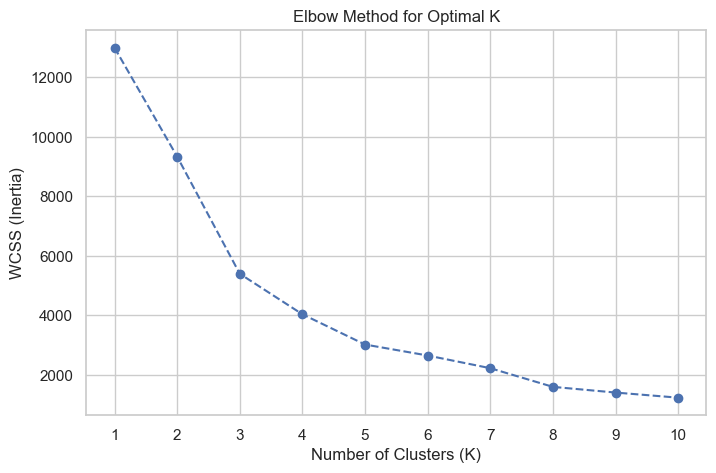

In [38]:
# 1. Calculate WCSS (Inertia) for K from 1 to 10

wcss = []
for k in range(1, 11):
    kmeans=KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)
    
# 2. Plot the Elbow Curve

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# **Conclusion of the Line Plot**

* **Elbow Method Output:** Plotted WCSS (Inertia) against cluster values from K=1 to 10.

* **Optimal Clusters Identified:** A distinct elbow bend appears at K=3 (and K=4), indicating the point where adding more clusters yields diminishing returns.
    
* **Next Step:** We will fit the K-Means model using K = 3 to segment customers into distinct behavioral groups(e.g., High-Value, At-Risk, Regular).   

# **Final Clustering Code**

In [40]:
# Apply final K-Means model with K=3

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

# Check cluster counts

print("=== CUSTOMER COUNT PER CLUSTER ===")
print(rfm['Cluster'].value_counts().sort_index())

# Display sample segmented customers

rfm.head()

**=== CUSTOMER COUNT PER CLUSTER ===**
Cluster
0    3220
1    1089
2      24
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12347,2,7,4310.00,0
1,12348,75,4,1437.24,0
2,12349,19,1,1457.55,0
3,12350,310,1,294.40,1
4,12352,36,7,1385.74,0


In [42]:
# Cluster Profiling : Average RFM values per cluster

cluster_profile = rfm.groupby('Cluster').agg({
    'Recency' : 'mean',
    'Frequency' : 'mean',
    'Monetary' : ['mean', 'count']
}).round(2)

print("=== CLUSTER PROFILING SUMMARY ===")
print(cluster_profile)

=== CLUSTER PROFILING SUMMARY ===
        Recency Frequency  Monetary      
           mean      mean      mean count
Cluster                                  
0         41.27      4.66   1836.03  3220
1        246.66      1.57    552.37  1089
2          6.33     70.58  82417.68    24


# **Conclusion**

**1. Cluster 0 (Regular Buyers - 3,220 customers):** Active customers with moderate recency (41.27 days) and steady spend (1836.03). Target with upsell offers and product recommendations.

**2. Cluster 1 (At-Risk / Inactive - 1,089 customers):** High recency (246.66 days) and low spend (552.37). Target with win-back email campaigns and discount vouchers.

**3. Cluster 2 (VIP / High-Value Champions - 24 customers):** Ultra-high spenders (82417.68) with frequent purchases (70.58 orders). Provide personalized premium service and exclusive loyalty rewards.

**Overall Outcome:** K-Means clustering successfully segmented the e-commerce customer base, enabling data-driven targeted marketing strategies.

# =====================================================
# TASK 6: VISUALIZE CLUSTERS USING SCATTER PLOTS
# =====================================================

**Handle Outliers for better visualization**

In [43]:
# Step 1 : Create a subset to handle outliers 

plot_data = rfm[(rfm['Frequency'] < 100) & (rfm['Monetary'] < 10000)]

print(plot_data)

      CustomerID  Recency  Frequency  Monetary  Cluster
0          12347        2          7   4310.00        0
1          12348       75          4   1437.24        0
2          12349       19          1   1457.55        0
3          12350      310          1    294.40        1
4          12352       36          7   1385.74        0
...          ...      ...        ...       ...      ...
4328       18280      278          1    180.60        1
4329       18281      181          1     80.82        1
4330       18282        8          2    178.05        0
4331       18283        4         16   2039.58        0
4332       18287       43          3   1837.28        0

[4234 rows x 5 columns]


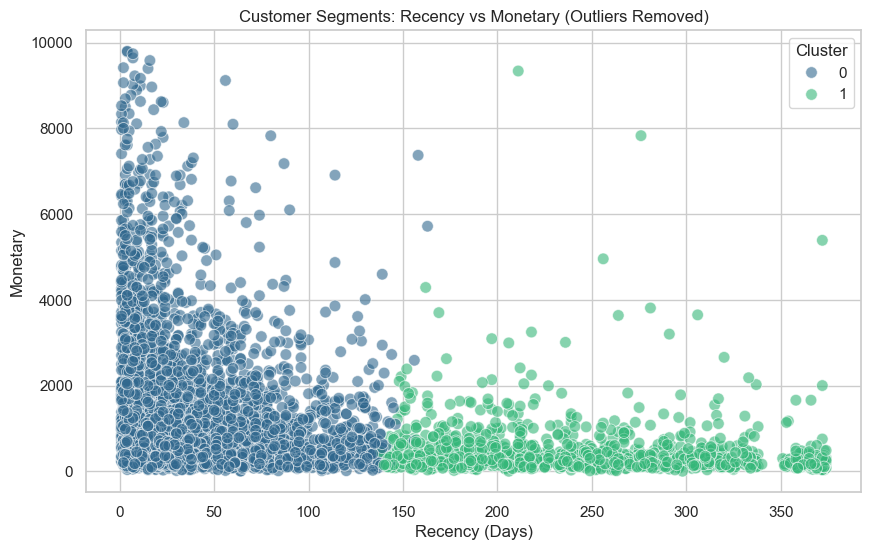

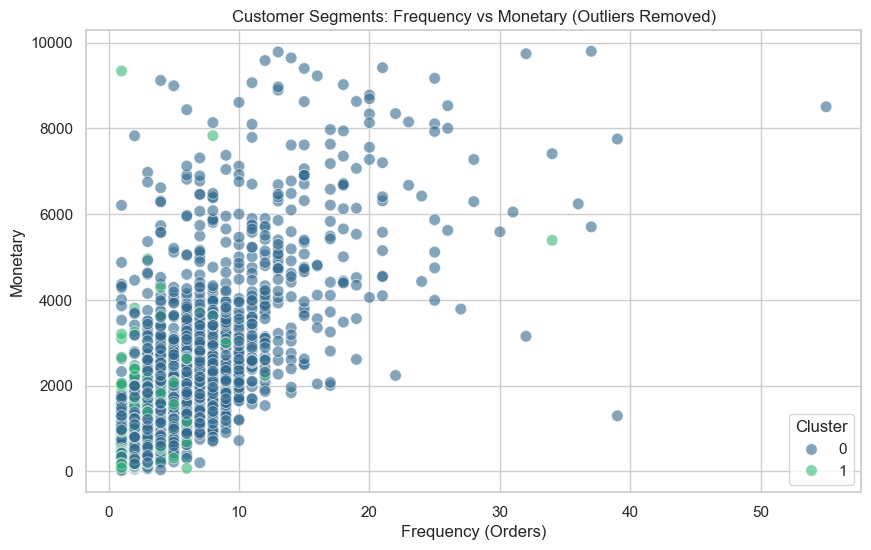

In [45]:
# Step 2: Scatter Plot 1 - Recency vs Monetary
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data, 
    x='Recency', 
    y='Monetary', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.6,
    s=70
)
plt.title('Customer Segments: Recency vs Monetary (Outliers Removed)')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


# Step 3: Scatter Plot 2 - Frequency vs Monetary
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data, 
    x='Frequency', 
    y='Monetary', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.6,
    s=70
)
plt.title('Customer Segments: Frequency vs Monetary (Outliers Removed)')
plt.xlabel('Frequency (Orders)')
plt.ylabel('Monetary')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# **Observation**

1. Recency vs Monetary Plot: Clearly displays the threshold around 140–150 days separating Active Regular Customers (Cluster 0) from Inactive At-Risk Customers (Cluster 1).

2. Frequency vs Monetary Plot: Illustrates a positive relationship where customers with higher order frequencies generate higher overall spending.

3. Final Verification: Visualizations confirm distinct segment boundaries without overlapping behavior, proving the success of our K-Means model.

# =====================================================
# TASK 7 : BAR CHART - CUSTOMERS PER CLUSTER
# =====================================================

C:\Users\lenovo\AppData\Local\Temp\ipykernel_19120\890033888.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


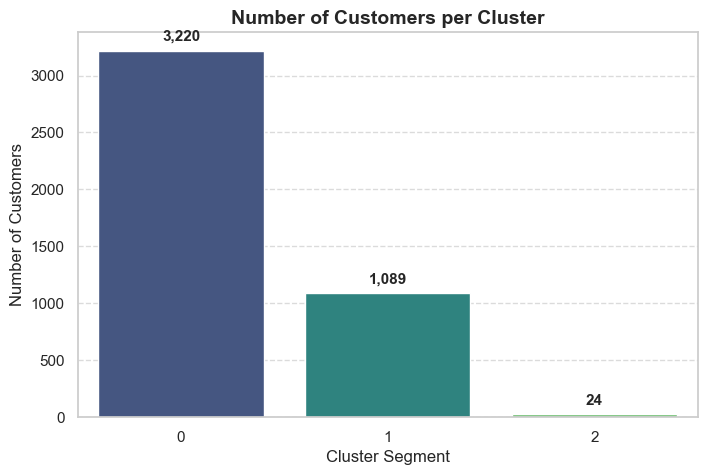

In [48]:
# Step 1: Count customers per cluster
cluster_counts = rfm['Cluster'].value_counts().sort_index()

# Step 2: Plot Bar Chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=cluster_counts.index, 
    y=cluster_counts.values, 
    palette='viridis'
)

# Step 3: Add titles & labels
plt.title('Number of Customers per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Step 4: Display exact value counts on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='bottom', 
        fontsize=11, fontweight='bold', 
        xytext=(0, 5), textcoords='offset points'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Observation**

**1. Dominant Segment:** Cluster 0 represents the majority of the customer base with 3,220 customers, forming the core revenue driver.

**2. Re-engagement Opportunity:** Cluster 1 holds 1,089 customers who need targeted retention and win-back strategies.

**3. High-Value Niche:** Cluster 2 consists of 24 VIP customers generating massive overall spend per head, requiring white-glove service.

**Final Status:** All tasks from data cleaning, RFM feature extraction, standardization, K-Means clustering, and visual profiling are successfully completed!

# **Business Insights**

### Business Insights & Marketing Recommendations

* **Cluster 0 (Regular Customers - 3,220):** 
  * **Strategy:** Encourage repeat buys and cross-selling.
  * **Actions:** Send personalized product recommendations and invite them to join a customer loyalty program.

* **Cluster 1 (At-Risk / Inactive Customers - 1,089):** 
  * **Strategy:** Re-engage and win back inactive users.
  * **Actions:** Send "We Miss You" email campaigns with targeted 15% discount vouchers.

* **Cluster 2 (VIP Champions - 24):** 
  * **Strategy:** High-touch retention and premium support.
  * **Actions:** Offer priority customer service, exclusive early sales access, and wholesale bulk discounts.